In [1]:
# Import Libraries
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, GRU, Input
import xgboost as xgb
from sklearn.metrics import mean_squared_error

In [3]:
# 1 Load NSEBANK Stock Data
end = datetime.now()
start = datetime(end.year - 10, end.month, end.day)
stock = "^NSEBANK"
stock_data = yf.download(stock, start, end)

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


In [5]:
# 2. Extract Close Prices
closing_price = stock_data[['Close']]

In [7]:
#Calculate Moving Averages if needed:
closing_price = closing_price.copy()
closing_price['MA_365'] = closing_price['Close'].rolling(window=365).mean()
closing_price['MA_100'] = closing_price['Close'].rolling(window=100).mean()

In [9]:
# 3. Normalize Data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(closing_price[['Close']].values)


In [11]:
# 4. Prepare Training Data for GRU
x_data, y_data = [], []
base_days = 100
for i in range(base_days, len(scaled_data)):
    x_data.append(scaled_data[i-base_days:i])
    y_data.append(scaled_data[i])
x_data, y_data = np.array(x_data), np.array(y_data)

In [13]:

# 5. Split Data into Training and Testing Sets (90% training)
len_train = int(len(x_data) * 0.9)
x_train, y_train = x_data[:len_train], y_data[:len_train]
x_test, y_test = x_data[len_train:], y_data[len_train:]

In [15]:
# 6. Build GRU Model for Feature Extraction
gru_model = Sequential([
    Input(shape=(x_train.shape[1], 1)),
    GRU(128, return_sequences=True),
    GRU(64, return_sequences=False),
    Dense(25, activation='relu'),  # Feature extraction layer
    Dense(1)
])
gru_model.compile(optimizer='adam', loss='mean_squared_error')
gru_model.fit(x_train, y_train, batch_size=5, epochs=10)

Epoch 1/10
376/376 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - loss: 0.0104
Epoch 2/10
376/376 ━━━━━━━━━━━━━━━━━━━━ 15s 40ms/step - loss: 2.3981e-04
Epoch 3/10
376/376 ━━━━━━━━━━━━━━━━━━━━ 17s 46ms/step - loss: 2.4171e-04
Epoch 4/10
376/376 ━━━━━━━━━━━━━━━━━━━━ 16s 43ms/step - loss: 1.8622e-04
Epoch 5/10
376/376 ━━━━━━━━━━━━━━━━━━━━ 16s 43ms/step - loss: 1.9690e-04
Epoch 6/10
376/376 ━━━━━━━━━━━━━━━━━━━━ 15s 40ms/step - loss: 1.8819e-04
Epoch 7/10
376/376 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - loss: 1.6287e-04
Epoch 8/10
376/376 ━━━━━━━━━━━━━━━━━━━━ 15s 41ms/step - loss: 1.7157e-04
Epoch 9/10
376/376 ━━━━━━━━━━━━━━━━━━━━ 16s 42ms/step - loss: 2.1449e-04
Epoch 10/10
376/376 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - loss: 2.4814e-04


In [17]:
# 7. Extract Features from GRU Model (for the entire dataset)
gru_features = gru_model.predict(x_data)
gru_features = gru_features.reshape(-1, 1)


66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step


In [19]:
# 8. Prepare Data for XGBoost
# Concatenate the GRU-extracted features with the original scaled data (starting from index 'base_days')
features = np.concatenate([gru_features, scaled_data[base_days:]], axis=1)
xgb_train, xgb_test = features[:len_train], features[len_train:]

In [21]:
# 9. Train XGBoost Model
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1)
xgb_model.fit(xgb_train, y_train.flatten())

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [23]:
# 10. Make Predictions Using the Hybrid Model
gru_preds = gru_model.predict(x_test)
xgb_preds = xgb_model.predict(xgb_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


In [25]:

# Blend Predictions: Use a weighted average (e.g., 60% GRU, 40% XGBoost)
final_predictions = 0.6 * gru_preds + 0.4 * xgb_preds.reshape(-1, 1)

In [27]:
# 11. Inverse Transform Predictions and True Values to Original Scale
inv_predictions = scaler.inverse_transform(final_predictions)
inv_y_test = scaler.inverse_transform(y_test)

In [29]:
# 12. Evaluate the Model (e.g., calculate RMSE)
rmse = np.sqrt(mean_squared_error(inv_y_test, inv_predictions))
print("GRU+XGBoost RMSE:", rmse)


GRU+XGBoost RMSE: 1712.1567566872477


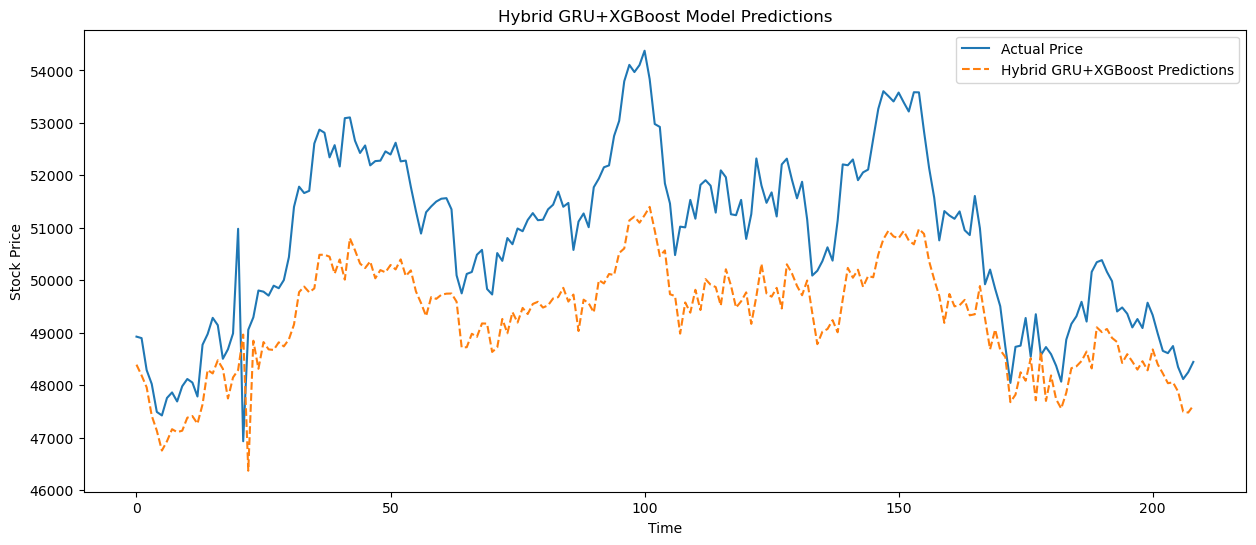

In [31]:
# 13. Plot Results
plt.figure(figsize=(15,6))
plt.plot(inv_y_test, label='Actual Price')
plt.plot(inv_predictions, label='Hybrid GRU+XGBoost Predictions', linestyle='dashed')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.title('Hybrid GRU+XGBoost Model Predictions')
plt.legend()
plt.show()

In [33]:
# 14. Save GRU Model for Web Use
gru_model.save("gru_xgb_model.keras")